# DSCI 100 Individual Report
## Completed by Sophia Meng, Group 7 Section 008

## Data Description of Players Dataset
This dataset and the following `sessions` dataset was taken from the research group The Pacific Laboratory for Artificial Intelligence (PLAI). They collected behavioural data on their MineCraft server, PlaiCraft. This was done by recording the gameplay, speech, and key presses in the PLAICraft Minecraft browser window. This project aims to collect data to develop a complex embodied AI, which can act, think, and learn in a virtual environment such as MineCraft. 

There are 196 observations in the `players` dataset. 

There are a total of seven variables in the `players` dataset. The variables in this dataset are:

- `experience` (categorical) - The experience level of the player described with five categories (`Pro`, `Veteran`, `Amataeur`, `Regular`, `Beginner`)
- `subscribe` (categorical) - Whether the player is subscribed to the game-related newsletter described as a Boolean 
- `hashedEmail`(categorical) - Email address of participant
- `played_hours` (quantitative) - Total hours played by the participant
- `name` (categorical) - The name of the participant
- `gender` (categorical) - Gender of the participant
- `Age` (quantitative) - Age of the participant

Some issues that arise with this data is that it will inherently be biased due to the method of collection. Players who already own MineCraft, and thus, may be more likely to be classified as `Pro` or `Veteran`, will not see much benefit to playing on the PlaiCraft server. Unless they are curious enough to want to help the topic of research, many will still play on the server they are comfortable with. As a result, most of the playerbase of PlaiCraft will be people who want to take advantage of the free server. These people most likely would be classified as `Beginner` or `Amataeur`. This causes the data to not be as representative of the whole population who plays video games like MineCraft.


## Data Description of Sessions Dataset
There are 1535 observations in the `sessions` dataset. 

There are a total of five variables in the `sessions` dataset. The variables in this dataset are:

- `hashedEmail`(categorical) - Email address of participant
- `start_time` (categorical) - 
- `end_time` (categorical) - 
- `original_start_time` (categorical) - 
- `original_end_time` (categorical) - 

## Questions

The broad question that was selected was the following:

"We would like to know which "kinds" of players are most likely to contribute a large amount of data so that we can target those players in our recruiting efforts."

Specifically, I am interested in if the experience level reported by the player affects how much they are playing. I hypothesize that the lower experience, the more likely the player is likely to play for longer hours. Within these categories, I am also interested if are trends within age groups and the amount of hours played.

In [1]:
### Load necessary packages
library(tidyverse)
library(repr)
library(tidymodels)
options(repr.matrix.max.rows = 6)
source('cleanup.R')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

ERROR: Error in file(filename, "r", encoding = encoding): cannot open the connection


In [2]:
players <- read_csv("data/players.csv")
sessions <- read_csv("data/sessions.csv")
players

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


In [4]:
sum_hours <- summarize(players,
          min_hours = min(played_hours, na.rm = TRUE),
          max_hours = max(played_hours, na.rm = TRUE))

sum_age <- summarize(players,
          min_age = min(Age, na.rm = TRUE),
          max_age = max(Age, na.rm = TRUE))
count_exp <- count(players, experience)
count_gender <- count(players, gender)
count_sub <- count(players, subscribe)

sum_hours
sum_age
count_exp
count_gender
count_sub

min_hours,max_hours
<dbl>,<dbl>
0,223.1


min_age,max_age
<dbl>,<dbl>
9,58


experience,n
<chr>,<int>
Amateur,63
Beginner,35
Pro,14
Regular,36
Veteran,48


gender,n
<chr>,<int>
Agender,2
Female,37
Male,124
⋮,⋮
Other,1
Prefer not to say,11
Two-Spirited,6


subscribe,n
<lgl>,<int>
FALSE,52
TRUE,144


In [ ]:
mean_values <- players |>
               mutate(average_hours_played = mean(played_hours, na.rm = TRUE),
                      average_age = mean(Age, na.rm = TRUE)) |>
               select(average_hours_played, average_age) |>
               slice(1)
mean_values

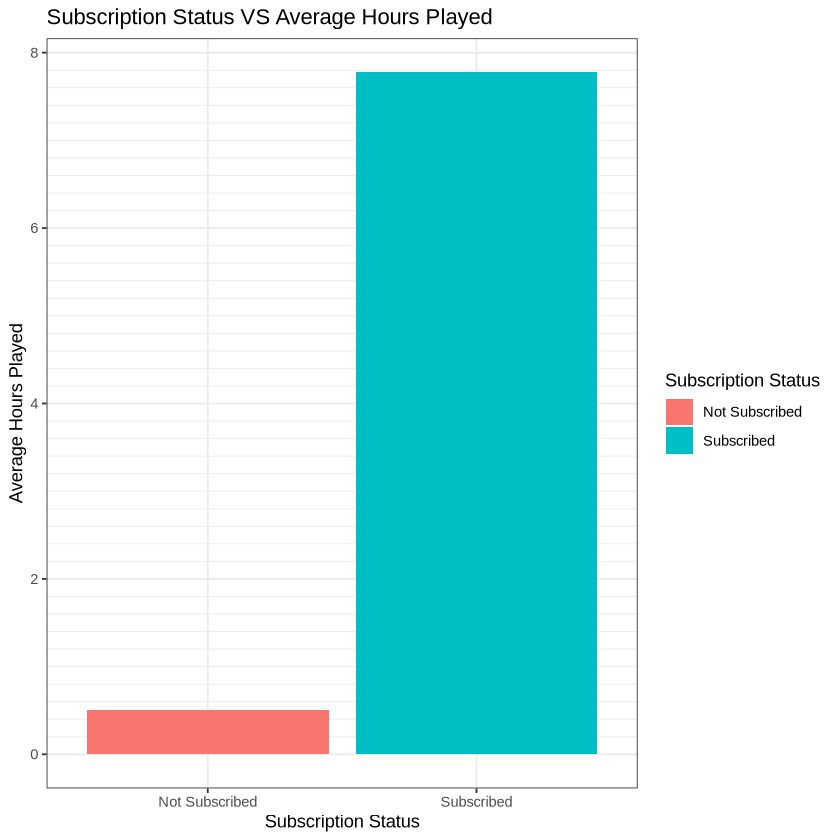

Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_bar()`).”


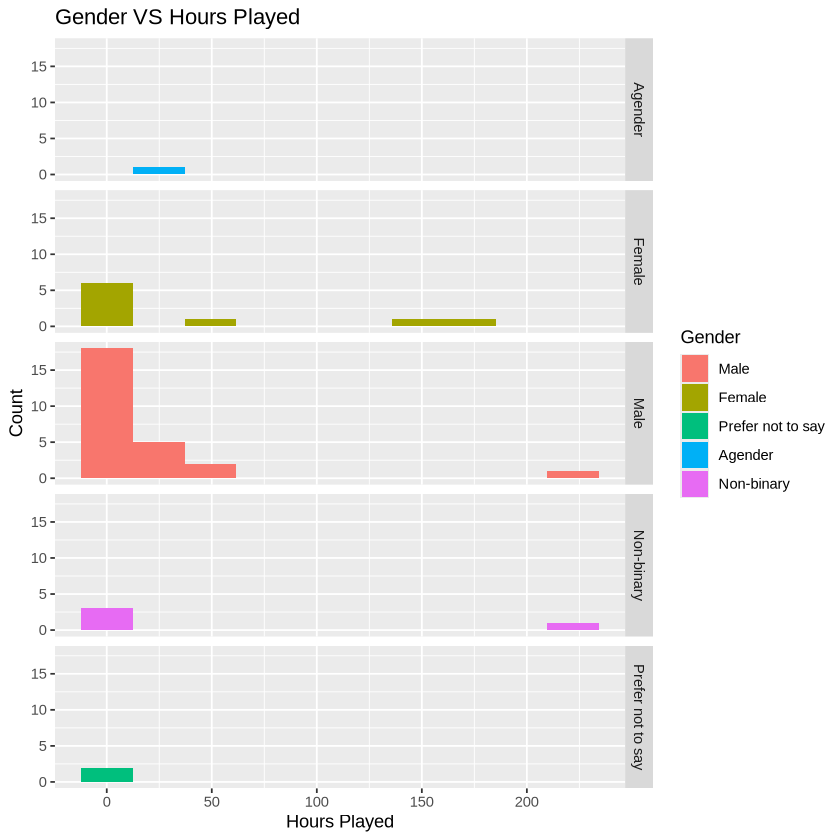

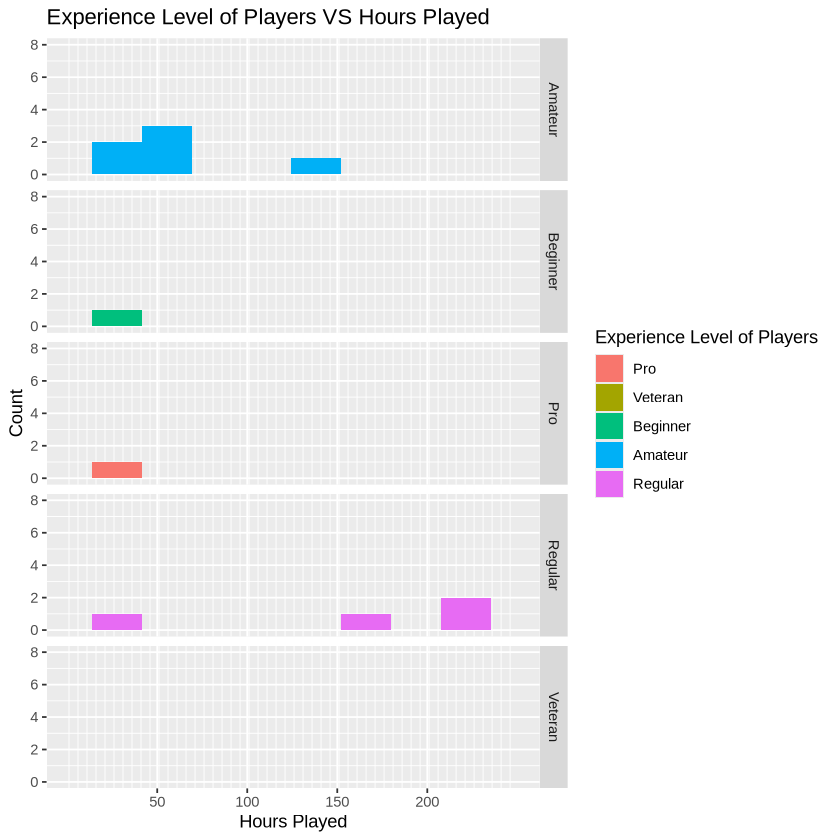

In [5]:
gender_graph <- players |>
               ggplot(aes(x = played_hours, fill = as_factor(gender))) +
               geom_histogram() +
               facet_grid(rows = vars(gender)) +
               xlab("Hours Played") +
               ylab("Count")

gender_graph_one <- players |>
               filter(played_hours >= 1) |>
               ggplot(aes(x = played_hours, fill = as_factor(gender))) +
               geom_histogram(bins = 10) +
               labs(fill = "Gender", title = "Gender VS Hours Played") +
               facet_grid(rows = vars(gender)) +
               xlab("Hours Played") +
               ylab("Count")

experience_graph <- players |>
               ggplot(aes(x = Age, fill = as_factor(experience))) +
               geom_histogram() +
               facet_grid(rows = vars(experience)) +
               xlab("Age") +
               ylab("Count")

experience_graph_hour <- players |>
               filter(played_hours >= 1) |>
               ggplot(aes(x = played_hours, fill = as_factor(experience))) +
               geom_histogram(bins = 10) +
               labs(fill = "Experience Level of Players",
                    title = "Experience Level of Players VS Hours Played") + 
               facet_grid(rows = vars(experience)) +
               xlab("Hours Played") +
               ylab("Count") + 
               scale_x_continuous(minor_breaks = seq(1, 250, by = 5),
                                 limits = c(1, 250), breaks = seq(50, 200, by = 50))

mean_subscribe <- players |>
               filter(subscribe == TRUE) |>
               mutate(average_hours_played = mean(played_hours, na.rm = TRUE),
                      average_age = mean(Age, na.rm = TRUE)) |>
               select(average_hours_played) |>
               slice(1)

mean_not_subscribe <- players |>
               filter(subscribe == FALSE) |>
               mutate(average_hours_played = mean(played_hours, na.rm = TRUE),
                      average_age = mean(Age, na.rm = TRUE)) |>
               select(average_hours_played) |>
               slice(1)

subscribe <- full_join(mean_subscribe, mean_not_subscribe, by = "average_hours_played") |>
             mutate(subscription_status = if_else(average_hours_played > 2, "Subscribed", "Not Subscribed"))

subscribe_graph <- subscribe |>
                   ggplot(aes(y = average_hours_played, x = subscription_status, fill = subscription_status)) + 
                   geom_bar(stat = "identity") +
                   labs(fill = "Subscription Status", title = "Subscription Status VS Average Hours Played") + 
                   xlab("Subscription Status") +
                   ylab("Average Hours Played") +
                   scale_y_continuous(minor_breaks = seq(0, 8, by = 0.2)) + 
                   theme_bw()

linear_maybe <- players |> 
               ggplot(aes(x = Age, y = played_hours)) +
               geom_point() +
               xlab("Age") +
               ylab("Hours Played") +
               ggtitle("Hours Played as a function of Age")

subscribe_graph

gender_graph_one

experience_graph_hour

## Methods and Plan

In order to tell if a player will be a "helpful" player, we can develop a model to predict based off information of the player if they are likely to be a player that would contribute data. This can be done by setting a benchmark of how many playing hours defines whether a player will be "helpful". This would likely be a low threshold, at maximum one hour of playing, due to the fact that one hour is seemingly a lot of time already and would likely still benefit this research. Using this threshold, we can try to create a KNN model using all variables except `hashedEmail` and `name` to predict the likelihood of this player playing at least one hour on the server. 

I believe this method is appropiate as it can be seen that there are many predictive variables and that not all of them have very clear linear correlations with `played_hours`. In fact, the plot of Age VS Played Hours does not show any clear signs of a linear relationship. As a result, linear regression is not a suitable method for this model. The KNN model is flexible and will work with little assumptions, only as long as there is enough of each category to make the prediction. The issue arrises when there are only a few of a categorical variable's points. 
This would be done by 